In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('CPU'))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm, metrics
from sklearn.model_selection import train_test_split

# 1. Load the handwritten digits dataset
# This dataset contains 8x8 pixel images of digits (0-9)
digits = datasets.load_digits()

# 2. Preprocess the data
# Flatten the 8x8 image matrices into a 1D array of 64 features per image
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# 3. Split data into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, shuffle=False
)

# 4. Initialize and train the Support Vector Classifier (SVC)
# 'gamma' controls the curvature of the decision boundary
classifier = svm.SVC(gamma=0.001)
classifier.fit(X_train, y_train)

# 5. Predict the digits on the test data
predicted = classifier.predict(X_test)

# 6. Evaluate the model performance
print(f"Classification report for classifier {classifier}:\n"
      f"{metrics.classification_report(y_test, predicted)}\n")

# 7. Visualize the first 4 test predictions
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, predicted):
    ax.set_axis_off()
    # Reshape the flattened 64-element array back to an 8x8 image for display
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")

plt.show()


ModuleNotFoundError: No module named 'sklearn'

Loading MNIST dataset...
Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)
Example label: 5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)


Training model...
Epoch 1/10


W0000 00:00:1789465124.467947   42463 cpu_allocator_impl.cc:82] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8841 - loss: 0.3759 - val_accuracy: 0.9782 - val_loss: 0.0870
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9631 - loss: 0.1217 - val_accuracy: 0.9845 - val_loss: 0.0586
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9727 - loss: 0.0886 - val_accuracy: 0.9862 - val_loss: 0.0479
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9770 - loss: 0.0733 - val_accuracy: 0.9862 - val_loss: 0.0469
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9796 - loss: 0.0654 - val_accuracy: 0.9900 - val_loss: 0.0378
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.9819 - loss: 0.0576 - val_accuracy: 0.9885 - val_loss: 0.0401
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9834 - loss: 0.0526 - val_accuracy: 0.9900 - val_loss: 0.0350
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.9846 - loss: 0.0491 - val_accurac

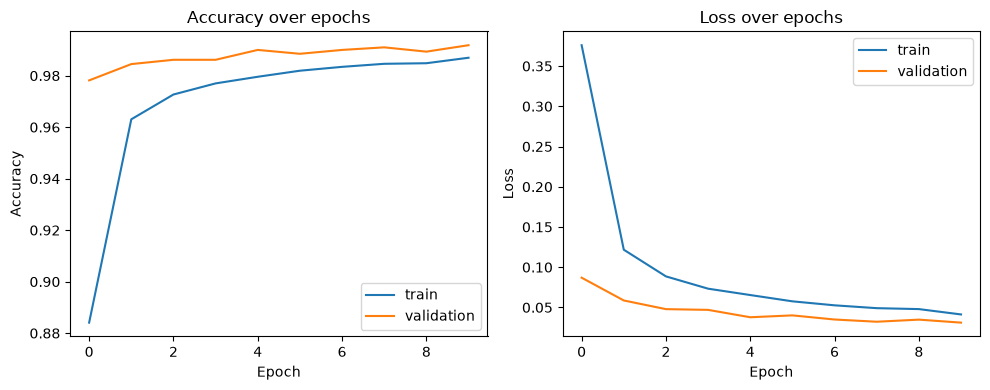

In [2]:
"""
Handwritten Digit Recognition with TensorFlow/Keras
=====================================================

This script trains a Convolutional Neural Network (CNN) to recognize
handwritten digits (0-9) using the MNIST dataset.

FIRST TIME SETUP:
    pip install tensorflow numpy matplotlib

If you're on a Mac with Apple Silicon, use:
    pip install tensorflow-macos tensorflow-metal

Then just run:
    python handwritten_digit_recognition.py

The first run will download the MNIST dataset automatically (~11MB).
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------
# STEP 1: Load the data
# -----------------------------------------------------------------------
# MNIST = a dataset of 70,000 grayscale images of handwritten digits (0-9),
# each 28x28 pixels. Keras ships with a built-in loader for it.
print("Loading MNIST dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images: {x_train.shape}")  # (60000, 28, 28)
print(f"Test images:     {x_test.shape}")   # (10000, 28, 28)

# Quick sanity check: look at one example
print(f"Example label: {y_train[0]}")  # e.g. 5

# -----------------------------------------------------------------------
# STEP 2: Preprocess the data
# -----------------------------------------------------------------------
# Neural networks train more reliably when input values are small
# (roughly between 0 and 1) rather than 0-255. This is called normalization.
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# CNN layers expect a "channels" dimension (1 for grayscale, 3 for RGB).
# Our images are (28, 28) -> we reshape to (28, 28, 1).
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Labels are integers (0-9). We convert them to "one-hot" vectors, e.g.
# label 3 becomes [0,0,0,1,0,0,0,0,0,0]. This matches the format the
# model's output layer will produce.
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# -----------------------------------------------------------------------
# STEP 3: Build the model
# -----------------------------------------------------------------------
# A CNN works by sliding small filters over the image to detect patterns
# like edges and curves (Conv2D), then shrinking the image while keeping
# the important info (MaxPooling2D), then making a final decision (Dense).
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),          # turn the 2D feature maps into a 1D vector
    layers.Dropout(0.5),       # randomly "turns off" neurons during training
                                # to prevent overfitting (memorizing instead
                                # of learning general patterns)
    layers.Dense(num_classes, activation="softmax"),  # 10 outputs, one per digit
])

model.summary()

# -----------------------------------------------------------------------
# STEP 4: Compile the model
# -----------------------------------------------------------------------
# - loss: how we measure "wrongness" during training (categorical
#   crossentropy is standard for multi-class classification)
# - optimizer: the algorithm that adjusts weights to reduce loss (adam is
#   a solid, widely-used default)
# - metrics: what we want to monitor besides loss (accuracy is intuitive)
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# -----------------------------------------------------------------------
# STEP 5: Train the model
# -----------------------------------------------------------------------
# - epochs: how many times the model sees the entire training set
# - batch_size: how many images it looks at before updating its weights
# - validation_split: holds back 10% of training data to check progress
#   on unseen data after each epoch
print("\nTraining model...")
history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
)

# -----------------------------------------------------------------------
# STEP 6: Evaluate on the test set
# -----------------------------------------------------------------------
# This tells us how well the model performs on images it has NEVER seen
# during training — the real measure of how good it is.
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")

# -----------------------------------------------------------------------
# STEP 7: Save the model
# -----------------------------------------------------------------------
model.save("digit_recognizer.keras")
print("Model saved as digit_recognizer.keras")

# -----------------------------------------------------------------------
# STEP 8: Visualize training progress (optional but useful)
# -----------------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_history.png")
print("Training curves saved as training_history.png")


# -----------------------------------------------------------------------
# STEP 9: Predict on a new image
# -----------------------------------------------------------------------
def predict_digit(image):
    """
    Predict the digit in a 28x28 grayscale image.
    `image` should be a numpy array of shape (28, 28) with values 0-255.
    """
    img = image.astype("float32") / 255.0
    img = np.expand_dims(img, axis=(0, -1))  # add batch + channel dims
    prediction = model.predict(img, verbose=0)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)
    return predicted_label, confidence


# Demo: predict on a few random test images
print("\nSample predictions:")
for i in range(5):
    label, confidence = predict_digit(x_test[i].squeeze() * 255)
    print(f"  True label: {y_test[i]} -> Predicted: {label} (confidence: {confidence:.2%})")

Loading EMNIST 'letters' dataset...
Number of classes: 37
Training examples: 88800
Test examples:     14800


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 245,925 (960.64 KB)

 Trainable params: 245,477 (958.89 KB)

 Non-trainable params: 448 (1.75 KB)


Training model...
Epoch 1/10


/home/rushi_m/Projects/OpenCV/.Ml_env/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


694/694 ━━━━━━━━━━━━━━━━━━━━ 84s 116ms/step - accuracy: 0.7812 - loss: 0.7275 - val_accuracy: 0.8896 - val_loss: 0.3083
Epoch 2/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 78s 112ms/step - accuracy: 0.8885 - loss: 0.3438 - val_accuracy: 0.9145 - val_loss: 0.2425
Epoch 3/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 78s 112ms/step - accuracy: 0.9058 - loss: 0.2865 - val_accuracy: 0.9193 - val_loss: 0.2356
Epoch 4/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 78s 112ms/step - accuracy: 0.9152 - loss: 0.2566 - val_accuracy: 0.9247 - val_loss: 0.2198
Epoch 5/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 76s 110ms/step - accuracy: 0.9199 - loss: 0.2375 - val_accuracy: 0.9239 - val_loss: 0.2213
Epoch 6/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.9238 - loss: 0.2217 - val_accuracy: 0.9265 - val_loss: 0.2100
Epoch 7/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 77s 110ms/step - accuracy: 0.9278 - loss: 0.2108 - val_accuracy: 0.9274 - val_loss: 0.2059
Epoch 8/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 77s 111ms/step - accuracy: 0.9303 - loss: 0.2022 - val

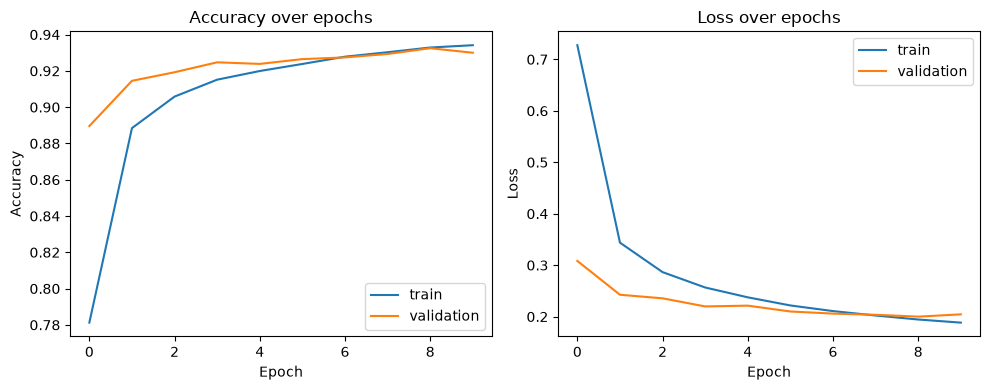

In [ ]:
"""
Handwritten Letter Recognition with TensorFlow/Keras (EMNIST)
================================================================

This extends the digit recognizer to full letters (A-Z) using the
EMNIST "letters" dataset — the same idea as MNIST, but for handwritten
letters instead of digits. It was built by the same people (NIST) using
the same image format, so the pipeline is nearly identical.

FIRST TIME SETUP:
    pip install tensorflow tensorflow-datasets numpy matplotlib

Then run:
    python handwritten_letter_recognition.py

The first run downloads the EMNIST dataset automatically (~500MB — bigger
than MNIST since it has ~145,000 letter images vs MNIST's 70,000 digits).
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import string

# -----------------------------------------------------------------------
# STEP 1: Load the data
# -----------------------------------------------------------------------
# EMNIST isn't built into keras.datasets like MNIST is, so we use
# TensorFlow Datasets (tfds), a library of ready-to-use datasets.
# The "letters" split has 26 balanced classes, one per letter (a-z),
# case-insensitive (so "A" and "a" share a label).
print("Loading EMNIST 'letters' dataset...")
(ds_train, ds_test), ds_info = tfds.load(
    "emnist/letters",
    split=["train", "test"],
    as_supervised=True,   # returns (image, label) pairs
    with_info=True,
)

num_classes = ds_info.features["label"].num_classes  # 27 (labels 1-26, 0 unused)
print(f"Number of classes: {num_classes}")
print(f"Training examples: {ds_info.splits['train'].num_examples}")
print(f"Test examples:     {ds_info.splits['test'].num_examples}")

# Label 0 is unused in this split; labels 1-26 map to a-z.
class_names = [""] + list(string.ascii_lowercase)  # index 0 = placeholder


# -----------------------------------------------------------------------
# STEP 2: Preprocess the data
# -----------------------------------------------------------------------
# Quirk worth knowing: EMNIST images are stored rotated and flipped
# compared to how you'd normally view them (an artifact of the original
# NIST format). We fix that with a transpose.
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0          # normalize to 0-1
    image = tf.transpose(image, perm=[1, 0, 2])          # fix EMNIST orientation
    label = tf.one_hot(label, num_classes)                # one-hot encode
    return image, label

BATCH_SIZE = 128

train_data = (
    ds_train
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_data = (
    ds_test
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# -----------------------------------------------------------------------
# STEP 3: Build the model
# -----------------------------------------------------------------------
# Same CNN pattern as the digit recognizer. Letters are a harder problem
# than digits (more classes, more visual similarity between some letters
# like "l" and "I"), so we add a bit more capacity.
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

model.summary()

# -----------------------------------------------------------------------
# STEP 4: Compile
# -----------------------------------------------------------------------
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# -----------------------------------------------------------------------
# STEP 5: Train
# -----------------------------------------------------------------------
print("\nTraining model...")
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
)

# -----------------------------------------------------------------------
# STEP 6: Evaluate
# -----------------------------------------------------------------------
test_loss, test_acc = model.evaluate(test_data, verbose=0)
print(f"\nTest accuracy: {test_acc:.4f}")

# -----------------------------------------------------------------------
# STEP 7: Save the model
# -----------------------------------------------------------------------
model.save("letter_recognizer.keras")
print("Model saved as letter_recognizer.keras")

# -----------------------------------------------------------------------
# STEP 8: Visualize training progress
# -----------------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("letter_training_history.png")
print("Training curves saved as letter_training_history.png")


# -----------------------------------------------------------------------
# STEP 9: Predict on a new image
# -----------------------------------------------------------------------
def predict_letter(image):
    """
    Predict the letter in a 28x28 grayscale image.
    `image` should be a numpy array of shape (28, 28) with values 0-255.
    """
    img = image.astype("float32") / 255.0
    img = np.expand_dims(img, axis=(0, -1))  # add batch + channel dims
    prediction = model.predict(img, verbose=0)
    predicted_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    return class_names[predicted_idx], confidence


# Demo: predict on a few test images
print("\nSample predictions:")
for images, labels in test_data.take(1):
    images_np = images.numpy()
    labels_np = labels.numpy()
    for i in range(20):
        true_idx = np.argmax(labels_np[i])
        letter, confidence = predict_letter(images_np[i].squeeze() * 255)
        print(f"  True label: {class_names[true_idx]} -> Predicted: {letter} (confidence: {confidence:.2%})")

In [4]:
"""
Recognize Handwritten Letters/Sentences from Video
====================================================

This script reads frames from a video file or webcam, finds
handwritten-character-shaped blobs in each frame, classifies each one
using the model trained by train_letter_model.py, and reconstructs
lines of text from the predictions.

HOW IT WORKS (since there's no single "video-to-text" layer):
  1. Grab a frame from the video/webcam.
  2. Threshold it so handwriting (dark) separates from the background
     (light) - like a black-and-white silhouette.
  3. Find contours (outlines of connected dark regions) - each one is a
     candidate character.
  4. Filter out contours that are too small/large to be a character
     (removes noise, smudges, etc).
  5. Group contours into lines (by vertical position) and sort each
     line left-to-right; large horizontal gaps become spaces.
  6. Crop, resize to 28x28, and feed each character into the model.
  7. Draw the results on the frame and print the recognized text.

HONEST LIMITATIONS:
  - This works best on clean, high-contrast handwriting (e.g. dark pen
    on white paper, filmed straight-on, good lighting) - not arbitrary
    handwriting "in the wild" (varying angles, cursive/connected
    letters, cluttered backgrounds).
  - Cursive/joined-up writing will NOT segment well, since this method
    assumes each character is a separate connected blob. Print
    handwriting works much better than cursive.
  - For production-grade OCR on messy real-world video, look into
    EAST (text detection) + CRNN with CTC loss (sequence recognition),
    or just use an existing OCR engine (Tesseract, EasyOCR) - they
    solve exactly this problem and don't require character segmentation.

SETUP:
    pip install tensorflow opencv-python numpy

Then run on a video file:
    python video_text_recognition.py --source my_video.mp4

Or on your webcam:
    python video_text_recognition.py --source 0
"""

import argparse
import cv2
import numpy as np
from tensorflow import keras

# -----------------------------------------------------------------------
# Load the trained model and class mapping (produced by
# train_letter_model.py). Falls back to digit-only classes if the
# letter model/mapping isn't found, so this script still runs against
# the simpler MNIST model from the first script.
# -----------------------------------------------------------------------
try:
    model = keras.models.load_model("letter_recognizer.keras")
    with open("emnist_classes.txt") as f:
        CLASSES = list(f.read().strip())
    print(f"Loaded letter_recognizer.keras ({len(CLASSES)} classes)")
except (OSError, IOError):
    model = keras.models.load_model("digit_recognizer.keras")
    CLASSES = list("0123456789")
    print("Loaded digit_recognizer.keras (digits only)")


def find_character_boxes(frame, min_area=100, max_area=20000):
    """
    Threshold the frame and return bounding boxes (x, y, w, h) of
    connected dark regions that are plausibly single characters.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu's method auto-picks a good threshold between "ink" and
    # "paper" based on the image's brightness histogram.
    _, thresh = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Thicken strokes slightly so broken pen strokes merge into one blob.
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    boxes = []
    for c in contours:
        x, y, w, h = cv2.boundingRect(c)
        area = w * h
        if min_area < area < max_area:
            boxes.append((x, y, w, h))

    return boxes, thresh


def group_into_lines(boxes, line_height_tolerance=0.6):
    """
    Group bounding boxes into text lines based on vertical (y) position,
    then sort each line left-to-right. Returns a list of lines, where
    each line is a list of boxes.
    """
    if not boxes:
        return []

    boxes = sorted(boxes, key=lambda b: b[1] + b[3] / 2)

    avg_height = np.mean([b[3] for b in boxes])
    lines = []
    current_line = [boxes[0]]
    current_y = boxes[0][1] + boxes[0][3] / 2

    for box in boxes[1:]:
        y_center = box[1] + box[3] / 2
        if abs(y_center - current_y) < avg_height * line_height_tolerance:
            current_line.append(box)
        else:
            lines.append(sorted(current_line, key=lambda b: b[0]))
            current_line = [box]
            current_y = y_center
    lines.append(sorted(current_line, key=lambda b: b[0]))

    return lines


def classify_character(thresh_img, box):
    """
    Crop a character region, pad it to a square, resize to 28x28
    (matching the training data), and run it through the model.
    """
    x, y, w, h = box
    crop = thresh_img[y:y + h, x:x + w]

    size = max(w, h)
    padded = np.zeros((size, size), dtype=np.uint8)
    x_off = (size - w) // 2
    y_off = (size - h) // 2
    padded[y_off:y_off + h, x_off:x_off + w] = crop

    margin = size // 4
    bordered = cv2.copyMakeBorder(
        padded, margin, margin, margin, margin,
        cv2.BORDER_CONSTANT, value=0
    )

    resized = cv2.resize(bordered, (28, 28))
    normalized = resized.astype("float32") / 255.0
    input_tensor = normalized.reshape(1, 28, 28, 1)

    prediction = model.predict(input_tensor, verbose=0)
    idx = np.argmax(prediction)
    confidence = np.max(prediction)
    return CLASSES[idx], confidence


def reconstruct_text(lines, confidence_threshold=0.5, space_gap_ratio=1.2):
    """
    Turn grouped/sorted boxes + their predicted characters into text,
    inserting spaces where the horizontal gap between characters is
    notably larger than the typical character width (word boundary).
    """
    text_lines = []
    for line in lines:
        avg_width = np.mean([b[0][2] for b in line])
        line_text = ""
        prev_right_edge = None

        for box, char, conf in line:
            if conf < confidence_threshold:
                continue
            x, y, w, h = box
            if prev_right_edge is not None:
                gap = x - prev_right_edge
                if gap > avg_width * space_gap_ratio:
                    line_text += " "
            line_text += char
            prev_right_edge = x + w

        if line_text:
            text_lines.append(line_text)

    return text_lines


def process_frame(frame):
    """Run the full pipeline on a single frame and return an annotated
    copy plus the recognized text lines."""
    boxes, thresh = find_character_boxes(frame)
    lines = group_into_lines(boxes)

    annotated = frame.copy()
    lines_with_predictions = []

    for line in lines:
        line_with_preds = []
        for box in line:
            char, conf = classify_character(thresh, box)
            line_with_preds.append((box, char, conf))

            x, y, w, h = box
            color = (0, 255, 0) if conf > 0.5 else (0, 165, 255)
            cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 2)
            cv2.putText(
                annotated, char, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2
            )
        lines_with_predictions.append(line_with_preds)

    text_lines = reconstruct_text(lines_with_predictions)
    return annotated, text_lines


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--source", default="0",
        help="Path to a video file, or a webcam index like 0 (default: 0)"
    )
    parser.add_argument(
        "--every_n_frames", type=int, default=5,
        help="Only run recognition every N frames, to keep things fast"
    )
    args, _unknown = parser.parse_known_args()

    source = int(args.source) if args.source.isdigit() else args.source
    cap = cv2.VideoCapture(source)

    if not cap.isOpened():
        print(f"Could not open video source: {args.source}")
        return

    frame_count = 0
    last_annotated = None

    print("Press 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % args.every_n_frames == 0:
            annotated, text_lines = process_frame(frame)
            last_annotated = annotated
            if text_lines:
                print("Recognized:", " | ".join(text_lines))
        else:
            annotated = last_annotated if last_annotated is not None else frame

        cv2.imshow("Handwriting Recognition", annotated)
        frame_count += 1

        if cv2.waitKey(0) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    main()

Loaded letter_recognizer.keras (47 classes)
Press 'q' to quit.


qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/rushi_m/Projects/OpenCV/.Ml_env/lib/python3.11/site-packages/cv2/qt/plugins"
QFont::fromString: Invalid description 'Noto Sans,11,-1,5,400,0,0,0,0,0,0,0,0,0,0,1,,0,0'
QFont::fromString: Invalid description 'Hack,11,-1,5,400,0,0,0,0,0,0,0,0,0,0,1,,0,0'
QFont::fromString: Invalid description 'Noto Sans,11,-1,5,400,0,0,0,0,0,0,0,0,0,0,1,,0,0'
QFont::fromString: Invalid description 'Noto Sans,11,-1,5,400,0,0,0,0,0,0,0,0,0,0,1,,0,0'
QFontDatabase: Cannot find font directory /home/rushi_m/Projects/OpenCV/.Ml_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/rushi_m/Projects/OpenCV/.Ml_env/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
Q

In [6]:
"""
Quick test: run the trained letter model on a single image file.
"""

import os
 
# Avoid a common Linux issue where OpenCV's bundled Qt can't find a
# "wayland" platform plugin. Must be set BEFORE cv2 is imported.
os.environ.setdefault("QT_QPA_PLATFORM", "xcb")


import cv2
import numpy as np
from tensorflow import keras

# Load the class mapping so we can turn a predicted index (0-46) back
# into an actual character.
with open("emnist_classes.txt") as f:
    CLASSES = list(f.read().strip())

model = keras.models.load_model("letter_recognizer.keras")

# --- Load and preprocess the image ---
img = cv2.imread("letters_img.jpg")
# img = cv2.imread("label_check/label_00.png")
if img is None:
    raise FileNotFoundError("Could not read A.png - check the path/filename")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# If your image is a dark letter on a light background (e.g. a photo of
# pen on paper), invert it so the letter becomes white on black - this
# is what the model was trained on (EMNIST stores ink as bright pixels).
# Comment this out if your image is already white-on-black.
gray = cv2.bitwise_not(gray)

# Resize to the 28x28 size the model expects.
resized = cv2.resize(gray, (28, 28))

# Normalize to 0-1, then reshape to (batch, height, width, channels).
normalized = resized.astype("float32") / 255.0
input_tensor = normalized.reshape(1, 28, 28, 1)

# --- Predict ---
predictions = model.predict(input_tensor, verbose=0)
idx = np.argmax(predictions)
confidence = np.max(predictions)

print(f"Predicted: '{CLASSES[idx]}'  (confidence: {confidence:.2%})")

# --- Display the (preprocessed) image alongside the prediction ---
# imshow needs a window name AND an image - not a prediction array.
display_img = cv2.resize(resized, (280, 280))  # upscale so it's visible
cv2.imshow(f"Predicted: {CLASSES[idx]}", display_img)

cv2.waitKey(0)  # waits indefinitely for any keypress
cv2.destroyAllWindows()

Predicted: 'N'  (confidence: 59.73%)


W0000 00:00:1789650509.864425   13819 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


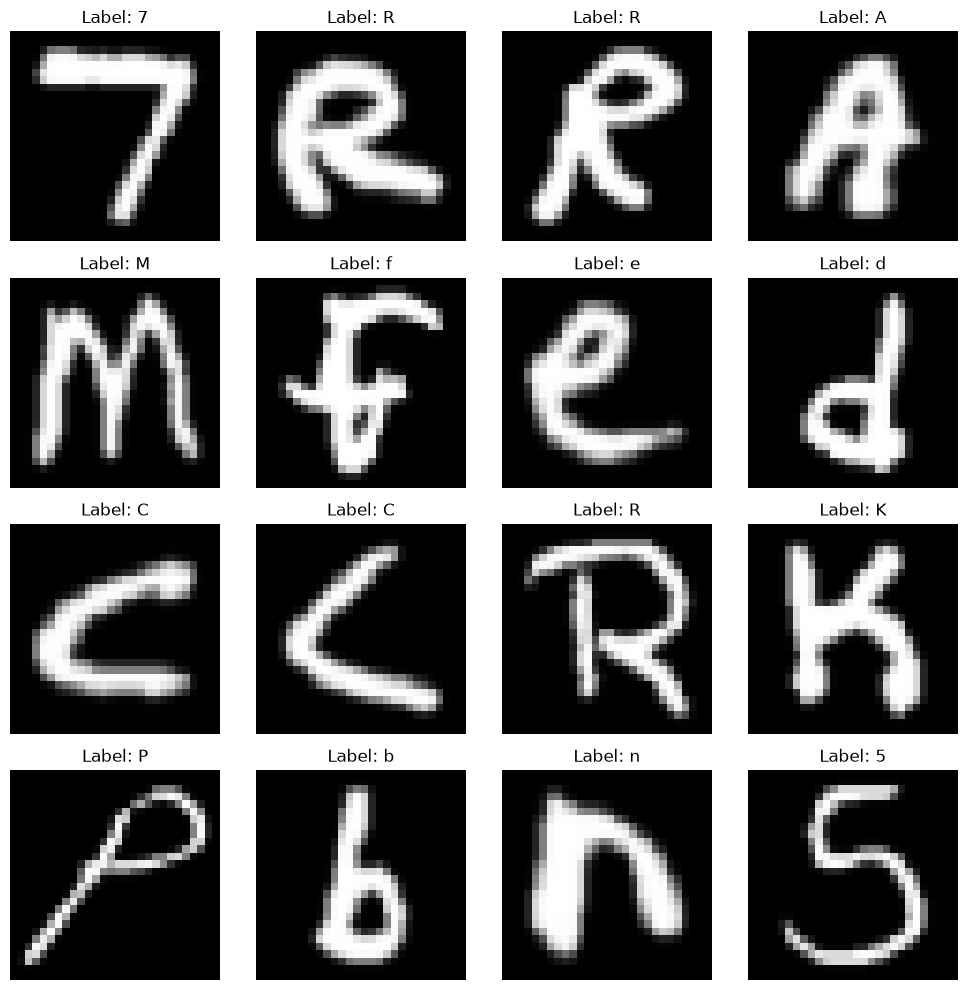

In [26]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

# 1. Define the official EMNIST Balanced character mapping list
# Index 0-9: Digits, 10-35: Uppercase, 36-46: Specific Lowercase
EMNIST_LABELS = [
    '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
    'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 
    'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
    'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'
]

# 2. Load the EMNIST Balanced dataset
# Note: TFDS automatically handles the 47-class 'balanced' split
dataset, info = tfds.load(
    'emnist/balanced', 
    split='train', 
    with_info=True, 
    as_supervised=True
)

# 3. Preprocessing function
def preprocess_emnist(image, label):
    # Normalize pixel values from [0, 255] to [0.0, 1.0]
    image = tf.cast(image, tf.float32) / 255.0
    
    # CRITICAL: Raw EMNIST images are transposed (rows and columns swapped).
    # We transpose them back and flip them to orient them correctly for display/training.
    image = tf.image.transpose(image)
    
    return image, label

# 4. Build the pipeline
batch_size = 16
dataset = dataset.map(preprocess_emnist).shuffle(1000).batch(batch_size)

# 5. Take one batch to verify and visualize
images, labels = next(iter(dataset))

plt.figure(figsize=(10, 10))
for i in range(batch_size):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().squeeze(), cmap='gray')
    
    # Map the integer label to the character string
    char_label = EMNIST_LABELS[labels[i].numpy()]
    
    plt.title(f"Label: {char_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()
